<a href="https://colab.research.google.com/github/GTGautam16/Curious-Projects/blob/main/Netflix_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Netflix Data Analysis Project

### Step 1: Project Introduction

**Problem Statement:**
Netflix is one of the most popular media and video streaming platforms. They have a massive amount of content. Analyzing this data can provide insights into their content strategy, regional focus, and audience preferences.

**Objectives:**
* Perform Exploratory Data Analysis (EDA) to understand content distribution.
* Identify trends in content additions over the years.
* Analyze the relationship between ratings, genres, and countries.

**Business Use Cases:**
* Content Acquisition: Understanding which genres are trending.
* Regional Strategy: Identifying countries with low content production for expansion.
* User Retention: Determining the optimal balance between Movies and TV Shows.

### Step 2: Import Libraries
We will use standard data science libraries for manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
%matplotlib inline
plt.style.use('fivethirtyeight')
warnings.filterwarnings('ignore')

### Step 3: Load Dataset
Note: Ensure you have uploaded the `netflix_titles.csv` file to your Colab session.

In [3]:
try:
    # Updating path to where the file is located in the environment
    df = pd.read_csv('/content/sample_data/netflix_titles.csv')
    print("Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("Error: 'netflix_titles.csv' not found. Please ensure the file is in /content/sample_data/.")

Dataset loaded successfully!


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Step 4: Data Cleaning

Before analysis, we must handle missing values, duplicates, and ensure data types are correct for time-based analysis.

In [4]:
# 1. Checking for missing values
print("Missing values per column:\n", df.isnull().sum())

# 2. Handling Missing Values
# Filling categorical columns with 'Unknown'
df['director'].fillna('No Director', inplace=True)
df['cast'].fillna('No Cast', inplace=True)
df['country'].fillna('Unknown', inplace=True)

# Dropping rows where critical info like date_added or rating is missing
df.dropna(subset=['date_added', 'rating'], inplace=True)

# 3. Handling Duplicates
df.drop_duplicates(inplace=True)

# 4. Data Type Conversion & Date Formatting
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

print("\nData cleaning complete. New shape:", df.shape)

Missing values per column:
 show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Data cleaning complete. New shape: (8793, 14)


### Step 5: Exploratory Data Analysis (EDA) & Step 6: Visualization

We will now dive into the data to extract insights using visualizations.

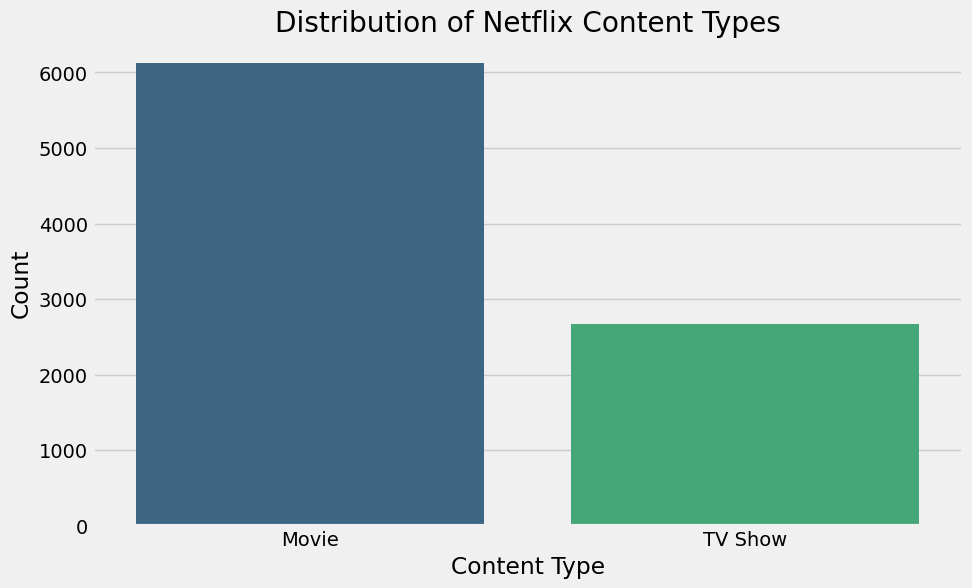

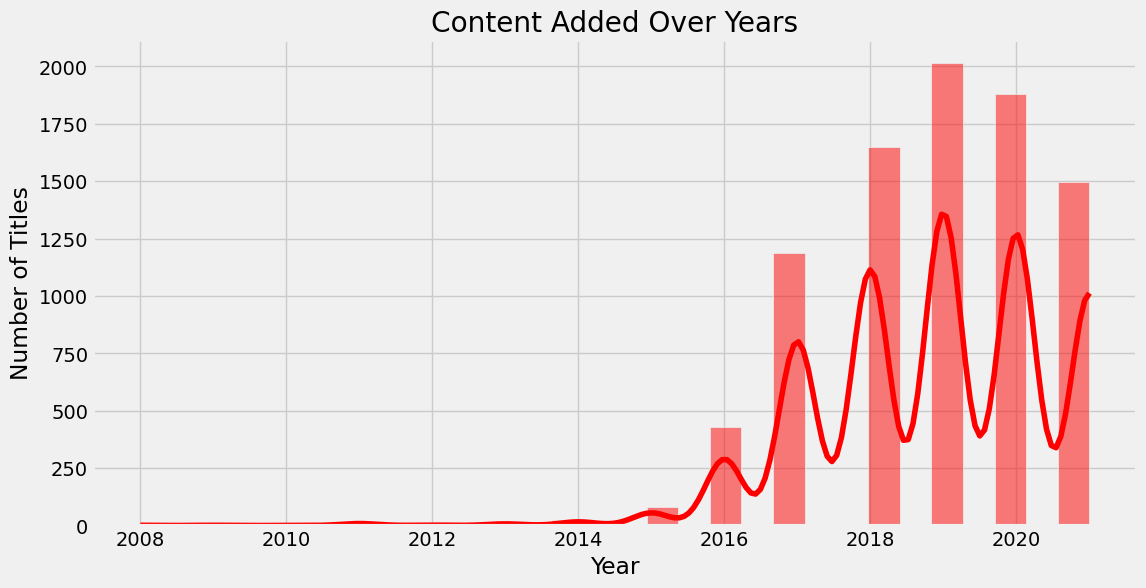

In [5]:
# 5.1 Movies vs TV Shows distribution
plt.figure(figsize=(10, 6))
plt.title("Distribution of Netflix Content Types")
sns.countplot(x='type', data=df, palette='viridis')
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

# 5.2 Content added over years
plt.figure(figsize=(12, 6))
plt.title("Content Added Over Years")
sns.histplot(df['year_added'], bins=30, kde=True, color='red')
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

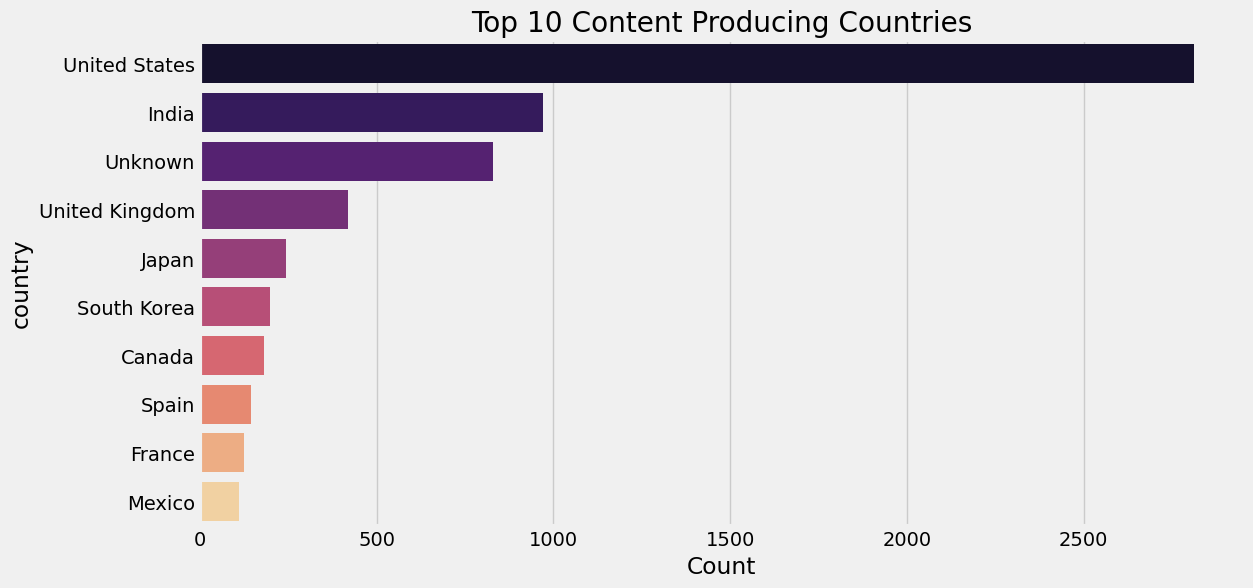

In [6]:
# 5.3 Top 10 countries producing content
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(12, 6))
plt.title("Top 10 Content Producing Countries")
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma')
plt.xlabel("Count")
plt.show()

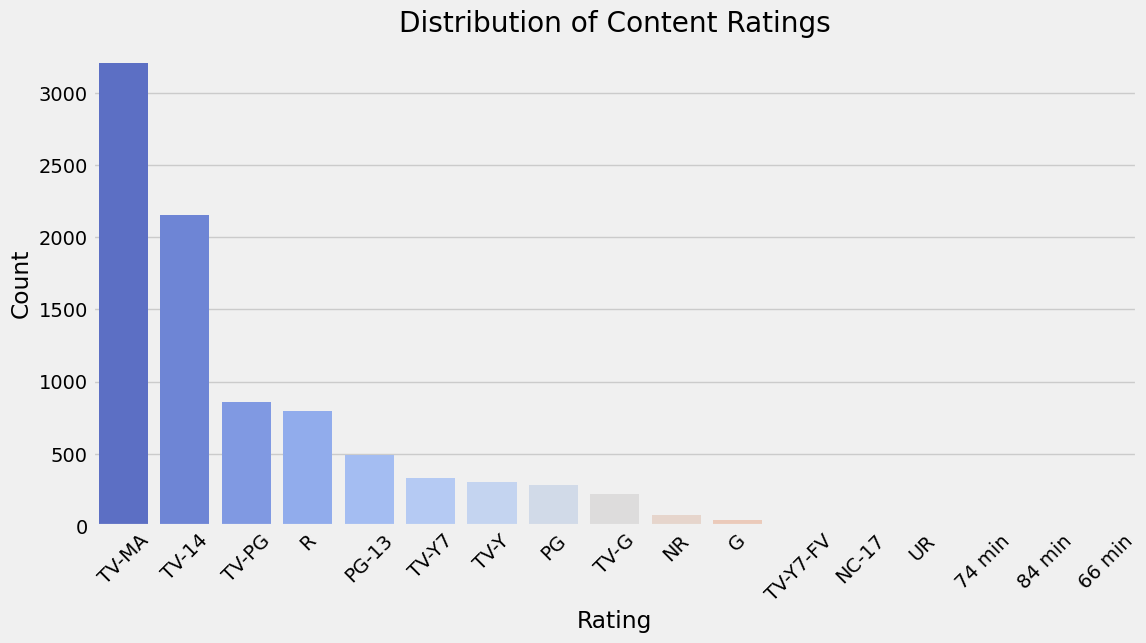

In [7]:
# 5.4 Most Common Ratings
plt.figure(figsize=(12, 6))
plt.title("Distribution of Content Ratings")
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='coolwarm')
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

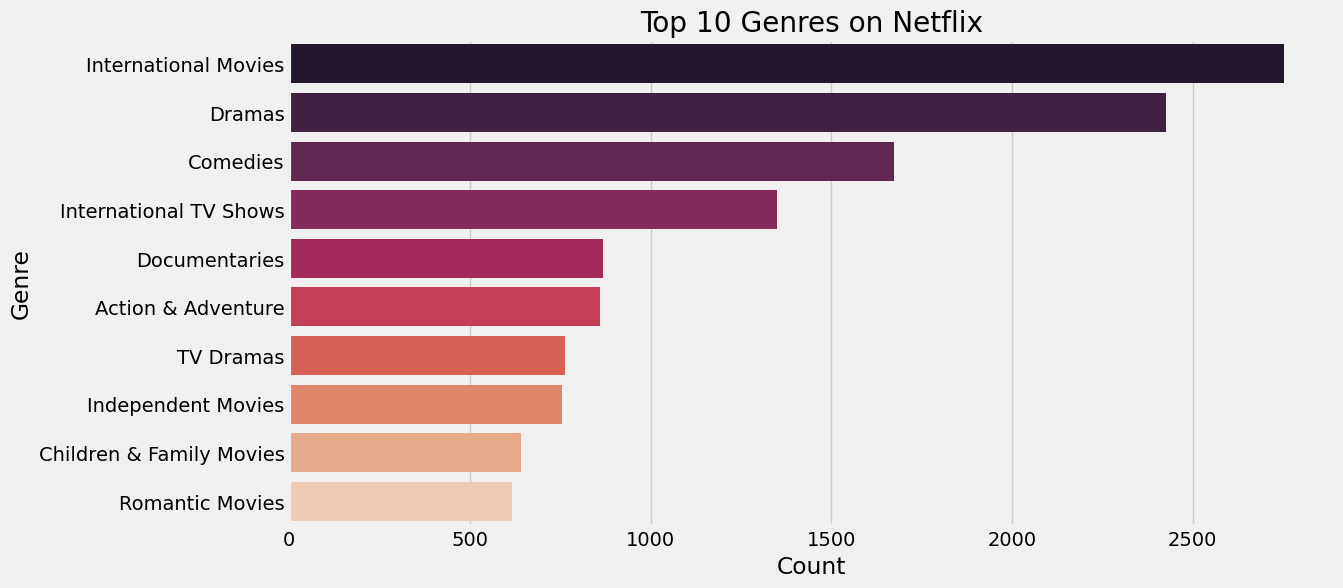

In [8]:
# 5.5 Genre Distribution (Handling multiple genres in one row)
from collections import Counter

genres = df['listed_in'].str.split(', ')
genre_counts = Counter([genre for sublist in genres for genre in sublist])
top_genres = pd.DataFrame(genre_counts.most_common(10), columns=['Genre', 'Count'])

plt.figure(figsize=(12, 6))
plt.title("Top 10 Genres on Netflix")
sns.barplot(x='Count', y='Genre', data=top_genres, palette='rocket')
plt.show()

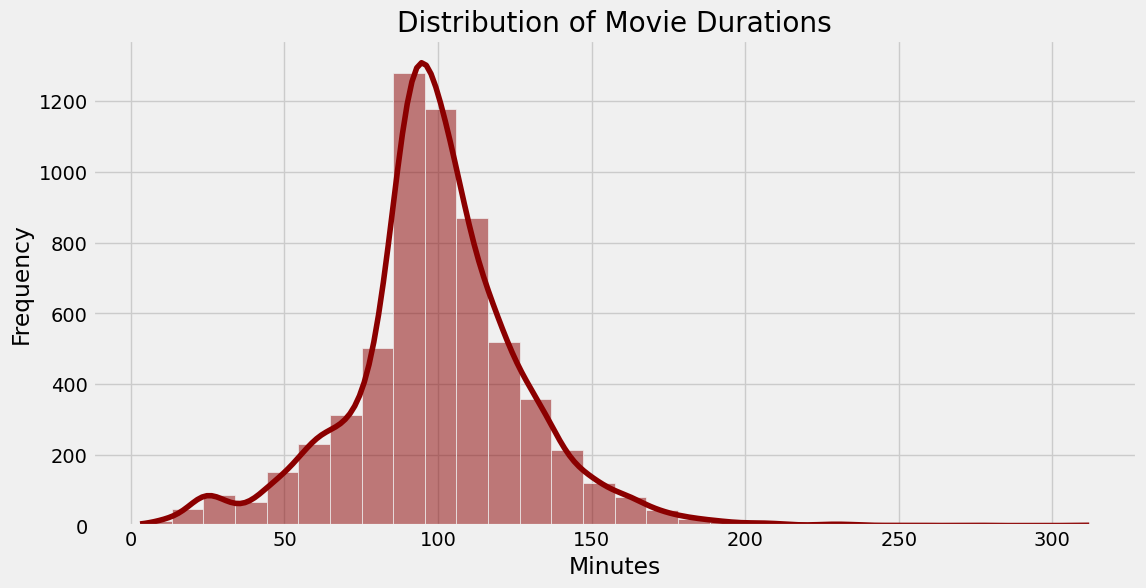

In [9]:
# 5.6 Duration Analysis
# Splitting Movies and TV Shows for duration analysis
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(12, 6))
sns.histplot(movies_df['duration_min'], bins=30, color='darkred', kde=True)
plt.title("Distribution of Movie Durations")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

### Step 7: Business Insights

Based on the analysis, here are the key business takeaways:
1. **Content Strategy:** Movies dominate the platform, but TV Shows have seen a steady growth in recent years.
2. **Regional Focus:** The United States and India are the largest content producers, suggesting a strong focus on these markets.
3. **Viewer Preferences:** Mature content (TV-MA) and Dramas/Comedies are the most prevalent, indicating the target audience demographic.
4. **Growth Trends:** Content additions peaked around 2018-2019, with a slight shift in production during 2020 due to global events.

### Step 8: Conclusion

**Key Findings:**
* Netflix focuses heavily on International Movies and Dramas.
* Content duration for movies typically ranges between 80 to 120 minutes.
* There is a significant amount of content with 'Unknown' directors, suggesting many licensed TV shows or missing metadata.

**Recommendations:**
* Diversify content production in emerging markets like South Korea and Mexico where growth is high.
* Optimize the balance between original productions and licensed content based on genre popularity.

### Step 9: Professional Deliverables

#### 1. Resume-Ready Description
**Netflix Data Analysis Project**
* Performed end-to-end exploratory data analysis (EDA) on a dataset of 8,000+ Netflix titles using Python (Pandas, NumPy).
* Cleaned and preprocessed data to handle missing values and formatted time-series data for trend analysis.
* Visualized key business metrics using Matplotlib and Seaborn, including content distribution, regional trends, and genre popularity.
* Derived actionable insights regarding Netflix's content acquisition strategy and regional market focus.

#### 2. Interview Q&A
* **Q: How did you handle missing values?** A: I filled categorical columns like 'director' and 'cast' with 'Unknown' to preserve data for other columns and dropped rows with missing 'date_added' or 'rating' as they were minimal.
* **Q: What was the most interesting finding?** A: The significant surge in content added after 2015, highlighting Netflix's aggressive expansion into original programming.

#### 3. GitHub README Snippet
```markdown
# Netflix Data Analysis
This project analyzes Netflix's content library to uncover insights about production trends, genre popularity, and geographical distribution.

## Tools Used
- Python (Pandas, NumPy)
- Visualization (Matplotlib, Seaborn)
- Google Colab
```